<a href="https://colab.research.google.com/github/BeastHunter0041/csci_4170_s26/blob/main/hw5_task1_CSCI4170.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification Project: Flowers Dataset

## Dataset
For this project, I used the **TensorFlow Flowers** dataset:  
https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz

This dataset contains flower images from 5 classes:
- daisy
- dandelion
- roses
- sunflowers
- tulips

This project includes:
1. A custom CNN built from Conv + MaxPooling layers
2. A transfer learning model using MobileNetV2
3. A custom CNN trained with data augmentation

In [ ]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs available:", tf.config.list_physical_devices('GPU'))
print("GPU device name:", tf.test.gpu_device_name())

if tf.config.list_physical_devices('GPU'):
    print("Running with GPU acceleration.")
else:
    print("No GPU detected. The notebook will still run, but training may be slower.")

TensorFlow version: 2.19.0
Built with CUDA: True
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU device name: /device:GPU:0
Running with GPU acceleration.


Download and Prepare the Dataset

In [ ]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

# Fix possible nested folder issue
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"

print("Dataset location:", data_dir)

Dataset location: /root/.keras/datasets/flower_photos/flower_photos


In [ ]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print("Total images:", image_count)

class_names = sorted([item.name for item in data_dir.iterdir() if item.is_dir()])
print("Classes:", class_names)

Total images: 3670
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## 2. Visualize the Dataset

We display sample images from the dataset to understand the classes and image variability.

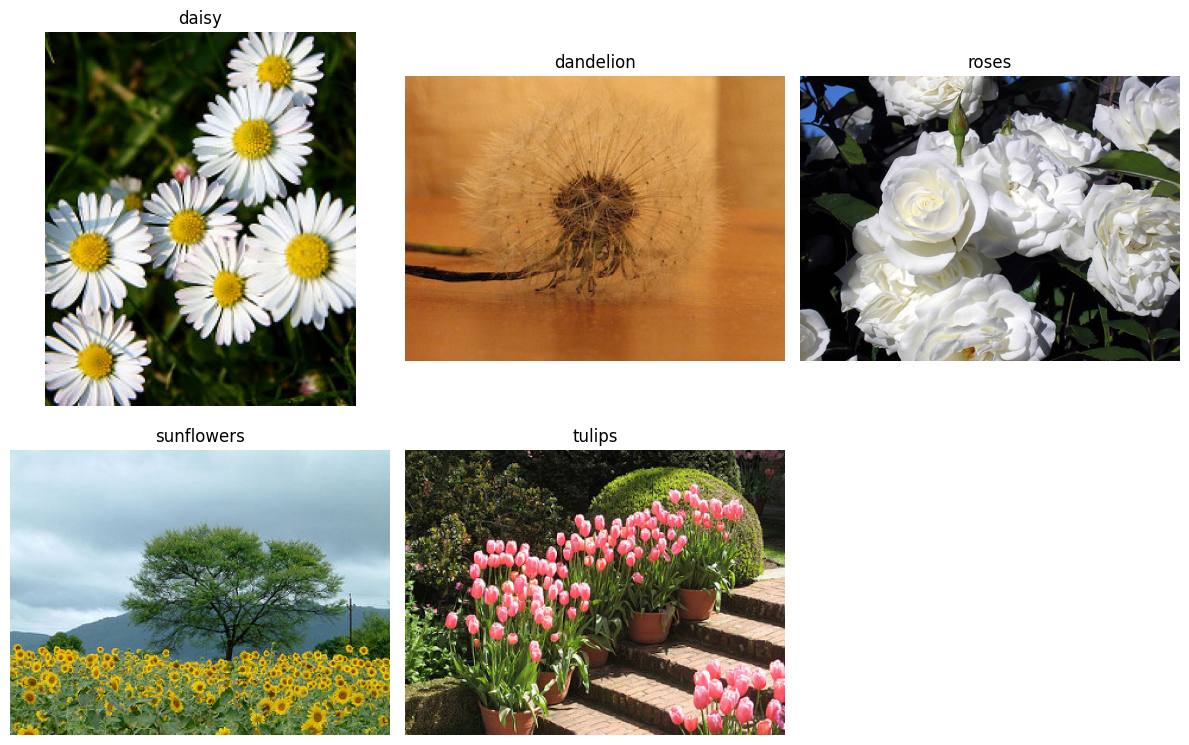

In [ ]:
plt.figure(figsize=(12, 8))

valid_classes = []

for class_name in class_names:
    class_dir = data_dir / class_name

    # collect common image extensions
    image_files = (
        list(class_dir.glob("*.jpg")) +
        list(class_dir.glob("*.jpeg")) +
        list(class_dir.glob("*.png"))
    )

    if len(image_files) > 0:
        valid_classes.append((class_name, image_files[0]))
    else:
        print(f"Skipping '{class_name}' because no image files were found.")

for i, (class_name, image_path) in enumerate(valid_classes[:6]):
    img = plt.imread(str(image_path))
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Parameters
batch_size = 32
img_height = 180
img_width = 180
seed = 123

In [ ]:
full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=None,
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

class_names = full_ds.class_names
num_classes = len(class_names)
print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 3670 files belonging to 5 classes.
Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5


In [ ]:
dataset_size = tf.data.experimental.cardinality(full_ds).numpy()
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

print("Total batches:", dataset_size)
print("Train batches:", train_size)
print("Val batches:", val_size)
print("Test batches:", test_size)

Total batches: 115
Train batches: 80
Val batches: 17
Test batches: 18


In [ ]:
full_ds = full_ds.shuffle(1000, seed=seed)

train_ds = full_ds.take(train_size)
remaining = full_ds.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

print("Train:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test:", tf.data.experimental.cardinality(test_ds).numpy())

Train: 80
Val: 17
Test: 18


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

##Part 1: Custom CNN Model

I chose a CNN with multiple Conv2D + MaxPooling2D blocks because:
- Early convolution layers learn simple patterns like edges and textures.
- Deeper convolution layers learn more complex class-specific features.
- MaxPooling reduces spatial size and computation while preserving important features.
- The number of filters increases across layers (32 → 64 → 128) so the network can learn progressively richer representations.

This is a common and effective pattern for moderate-sized image classification tasks.

In [ ]:
normalization_layer = layers.Rescaling(1./255)

In [ ]:
cnn_model = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    normalization_layer,

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,224,069 (8.48 MB)

 Trainable params: 2,224,069 (8.48 MB)

 Non-trainable params: 0 (0.00 B)

### Dense Layers Explanation
The final dense layers are used to:
- combine extracted feature maps into a learned representation
- apply dropout for regularization
- output class probabilities with a softmax layer

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
epochs = 12

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 124ms/step - accuracy: 0.4180 - loss: 1.3410 - val_accuracy: 0.5092 - val_loss: 1.0978
Epoch 2/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.5465 - loss: 1.0993 - val_accuracy: 0.6232 - val_loss: 0.9583
Epoch 3/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.6172 - loss: 0.9647 - val_accuracy: 0.6636 - val_loss: 0.8966
Epoch 4/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6578 - loss: 0.8685 - val_accuracy: 0.6507 - val_loss: 0.8625
Epoch 5/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6906 - loss: 0.7940 - val_accuracy: 0.7040 - val_loss: 0.7823
Epoch 6/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7156 - loss: 0.7193 - val_accuracy: 0.7537 - val_loss: 0.6285
Epoch 7/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7672 - loss: 0.6002 - val_accuracy: 0.7941 - val_loss: 0.5811
Epoch 8/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8039 - loss: 0.5114 - val_accuracy: 0.8180 -

We evaluate using:
- **Loss**: how far predictions are from the true labels
- **Accuracy**: percentage of correctly classified images

Accuracy is the main classification metric here, while loss helps show confidence and training quality.

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_ds)
print("Custom CNN Test Loss:", cnn_test_loss)
print("Custom CNN Test Accuracy:", cnn_test_acc)

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8854 - loss: 0.4982
Custom CNN Test Loss: 0.49820730090141296
Custom CNN Test Accuracy: 0.8854166865348816


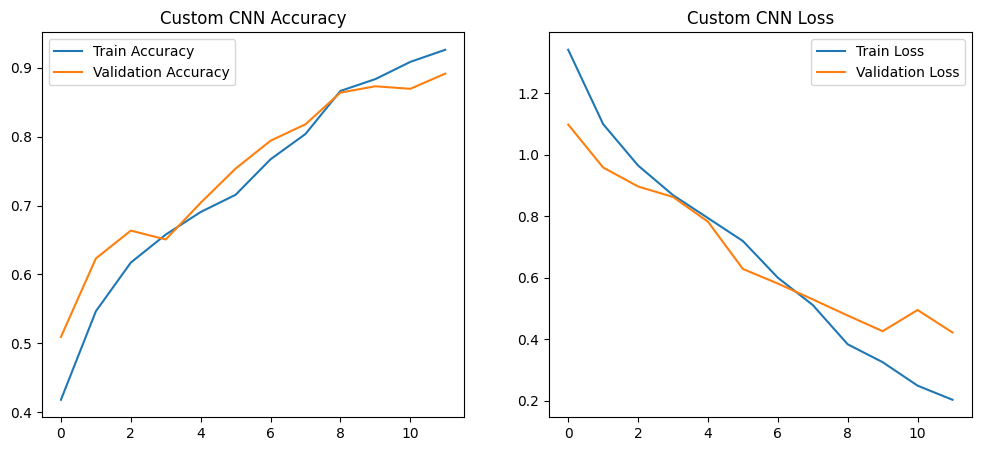

In [ ]:
acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']
loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Custom CNN Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Custom CNN Loss')

plt.show()

## Part 1 Discussion

The custom CNN learned steadily over training, with both training and validation accuracy increasing and both losses decreasing. Final validation performance was strong, though the gap between training and validation near the end suggests mild overfitting. Overall, the model showed that a standard Conv + MaxPooling architecture can classify this dataset effectively.

## Part 2: Transfer Learning with MobileNetV2

For transfer learning, I chose **MobileNetV2** because:
- it is widely used for image classification
- it is efficient and lightweight
- it was pretrained on a large image dataset, so it already learned useful visual features

I use the pretrained convolutional base and add my own classification head for the flower classes.

In [ ]:
base_model = MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

transfer_model = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

transfer_model.summary()

/tmp/ipykernel_40058/533750174.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 25s 93ms/step - accuracy: 0.6832 - loss: 0.8473 - val_accuracy: 0.8309 - val_loss: 0.4370
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8469 - loss: 0.4340 - val_accuracy: 0.8640 - val_loss: 0.3422
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8754 - loss: 0.3601 - val_accuracy: 0.9081 - val_loss: 0.2800
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8895 - loss: 0.3188 - val_accuracy: 0.9228 - val_loss: 0.2387
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8930 - loss: 0.2774 - val_accuracy: 0.9283 - val_loss: 0.2085
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9152 - loss: 0.2384 - val_accuracy: 0.9301 - val_loss: 0.2049
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9187 - loss: 0.2244 - val_accuracy: 0.9412 - val_loss: 0.1862
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9281 - loss: 0.2080 - val_accuracy: 0.9485 - 

In [ ]:
transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_ds)
print("MobileNetV2 Test Loss:", transfer_test_loss)
print("MobileNetV2 Test Accuracy:", transfer_test_acc)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9358 - loss: 0.2092
MobileNetV2 Test Loss: 0.20915725827217102
MobileNetV2 Test Accuracy: 0.9357638955116272


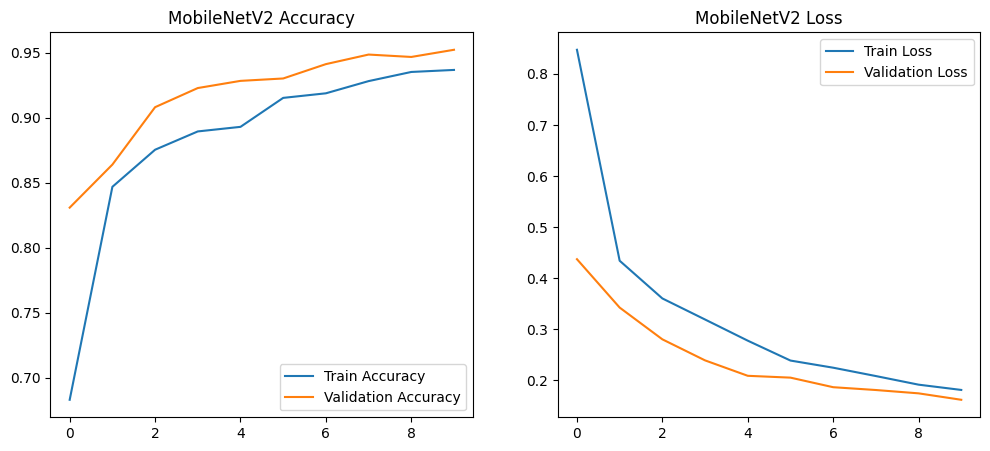

In [ ]:
acc = history_transfer.history['accuracy']
val_acc = history_transfer.history['val_accuracy']
loss = history_transfer.history['loss']
val_loss = history_transfer.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('MobileNetV2 Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('MobileNetV2 Loss')

plt.show()

##Part 2 Discussion

MobileNetV2 performed better than the custom CNN, reaching higher validation accuracy and lower validation loss while also converging faster. This is likely because it was pretrained on a large image dataset, so it started with stronger visual feature representations. Overall, transfer learning gave the best results and generalization.

##Part 3: Data Augmentation

To increase dataset diversity, I apply random transformations:
- horizontal flips
- small rotations
- zoom changes

This helps the model generalize better by exposing it to slightly altered versions of the same images during training.

In [ ]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

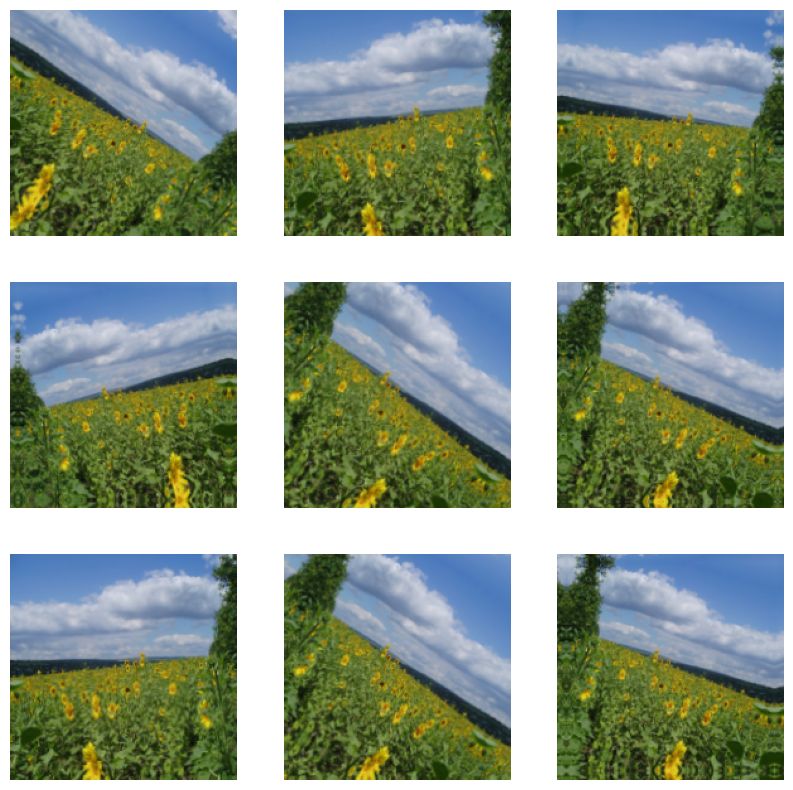

In [ ]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    first_image = images[0]
    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")
    plt.show()

Now I train the same custom CNN architecture as Part 1, but this time I include data augmentation at the start of the model.

In [ ]:
augmented_cnn_model = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

augmented_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 22, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,224,069 (8.48 MB)

 Trainable params: 2,224,069 (8.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
augmented_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_augmented = augmented_cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12
)

Epoch 1/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.3961 - loss: 1.3592 - val_accuracy: 0.5331 - val_loss: 1.1246
Epoch 2/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.5566 - loss: 1.0997 - val_accuracy: 0.6434 - val_loss: 0.9465
Epoch 3/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6105 - loss: 0.9746 - val_accuracy: 0.6526 - val_loss: 0.8344
Epoch 4/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6426 - loss: 0.9013 - val_accuracy: 0.6452 - val_loss: 0.8669
Epoch 5/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.6863 - loss: 0.8304 - val_accuracy: 0.6710 - val_loss: 0.8759
Epoch 6/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.6914 - loss: 0.8104 - val_accuracy: 0.7243 - val_loss: 0.7368
Epoch 7/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7074 - loss: 0.7613 - val_accuracy: 0.6875 - val_loss: 0.7919
Epoch 8/12
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7246 - loss: 0.7344 - val_accuracy: 0.7463 - v

In [ ]:
aug_test_loss, aug_test_acc = augmented_cnn_model.evaluate(test_ds)
print("Augmented CNN Test Loss:", aug_test_loss)
print("Augmented CNN Test Accuracy:", aug_test_acc)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7778 - loss: 0.6212
Augmented CNN Test Loss: 0.6211832165718079
Augmented CNN Test Accuracy: 0.7777777910232544


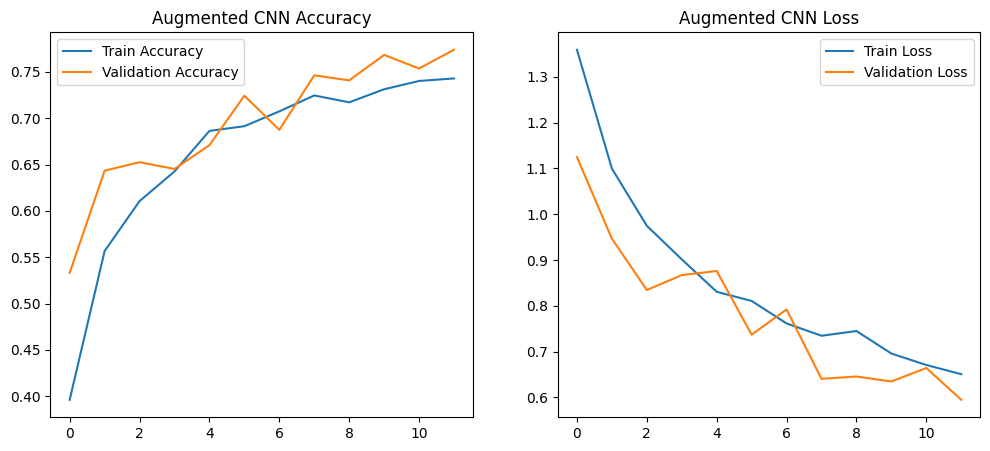

In [ ]:
acc = history_augmented.history['accuracy']
val_acc = history_augmented.history['val_accuracy']
loss = history_augmented.history['loss']
val_loss = history_augmented.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Augmented CNN Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Augmented CNN Loss')

plt.show()

##Part 3 Discussion

The augmented CNN improved more slowly and finished with lower accuracy than the original custom CNN. However, the training and validation curves stayed closer together, suggesting less overfitting. In this case, augmentation acted more as regularization than as a way to increase final accuracy.